# Off-target analysis

Using Cas-OFFinder: http://www.rgenome.net/cas-offinder/

- Up to 4 mismatches allowed
- No DNA or RNA bulges
- XCas9 3.7 (TLIKDIV SpCas9) from Streptococcus pyogenes: 5'-NG-3'
- hg38

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

In [19]:
#submitting in batches of 1000 gRNAs
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
protos = [i[1:] for i in library['proto_G+19']]

proto_list = list(np.unique(protos))
batch1 = proto_list[:1000]
batch2 = proto_list[1000:2000]
batch3 = proto_list[2000:3000]
batch4 = proto_list[3000:4000]
batch5 = proto_list[4000:5000]
batch6 = proto_list[5000:6000]
batch7 = proto_list[6000:7000]
batch8 = proto_list[7000:8000]
batch9 = proto_list[8000:9000]
batch10 = proto_list[9000:]

for i in batch10:
    print(i)

TTTTACTATGTAACTGTGT
TTTTACTCTTCCTCGCTCA
TTTTACTGAAATATTTCCT
TTTTAGCTGACATGGGTTT
TTTTAGGCCTCTTTTTCGT
TTTTAGTAAGTCCCGGGAA
TTTTAGTGTATTTGCCGGC
TTTTATATGGTTGCTGAGG
TTTTATCCCAGCCTGAAGC
TTTTATTCTTGTTCAATTC
TTTTATTTAGCTGCTGTTG
TTTTCAGGTGTGGAATAGC
TTTTCATCTAGCAACAAGT
TTTTCATTAAAATGAACCA
TTTTCCAATTTTACACTTC
TTTTCCAGACCGTCTGGTG
TTTTCCATAAGCAGAAGAC
TTTTCCATATACTTGATAA
TTTTCCTTTTTATTGCCAA
TTTTCGAGAAGTTTTGGAT
TTTTCGATGACTTTTACTC
TTTTCGTACAGCTCATAGT
TTTTCTAGGCAAAAATACA
TTTTCTCTTTAAGAGATAC
TTTTCTGAGGACCATATCA
TTTTCTTTGCACCTTTCCA
TTTTCTTTGGTTTCACCAT
TTTTGACTCTCCCCCTCTC
TTTTGAGGGTTCCACATCT
TTTTGATTTCACGAATGGC
TTTTGGAAGTTCTCCATGA
TTTTGGACTAAACAATAAA
TTTTTAAAGTTCCACCACT
TTTTTACTCTTCCTCGCTC
TTTTTCACTGTCGTCAGGA
TTTTTCCATATACTTGATA
TTTTTCGTGGAAGTTCAGA
TTTTTGAATTTCTGCACCA


# Processing output


In [40]:
OT_holder = []
for i in range(1,11):
    aa1 = pd.read_csv(f'../../source_data/17_off-targets/batch{i}.txt', sep='\t')
    print(i)
    mismatch_num = [0,1,2,3,4]

    guides = np.unique(aa1['crRNA'])

    num_g = len(guides)

    OT_df = pd.DataFrame(dict(zip(['gRNA_sequence', '0', '1', '2', '3', '4'], [guides, np.zeros(num_g), np.zeros(num_g), np.zeros(num_g), np.zeros(num_g), np.zeros(num_g)])))

    for mismatch in mismatch_num:
        subset = aa1[aa1['Mismatches']==mismatch]

        u, c = np.unique(subset['crRNA'], return_counts=True)
        ot_dict = dict(zip(u,c))

        for guide in u:
            OT_df.loc[OT_df['gRNA_sequence']==guide, f'{mismatch}']=ot_dict[guide]

    OT_holder.append(OT_df)

1
2
3
4
5
6
7
8
9
10


In [ ]:
off_targets = pd.concat(OT_holder)
off_targets['proto_G+19'] = [f'G{i[:-2]}' for i in off_targets['gRNA_sequence']]

library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')
l2 = library[['gRNA_id', 'proto_G+19', 'Gene', 'classification']]

OT_merge = pd.merge(off_targets, l2, on='proto_G+19', how='outer')
#OT_merge.to_csv('../../source_data/17_off-targets/OT_merge.csv', index=False)

In [58]:
#confirming non-targeting guides have no direct match
NT = OT_merge[OT_merge['classification']=='non-targeting control']
np.unique(NT['0'], return_counts=True)

(array([0.]), array([445]))

In [72]:
np.unique(OT_merge[OT_merge['0']>1]['classification'], return_counts=True)

(array(['intron', 'targeting'], dtype=object), array([100, 359]))

PearsonRResult(statistic=0.010554771827669196, pvalue=0.5814668968335474)

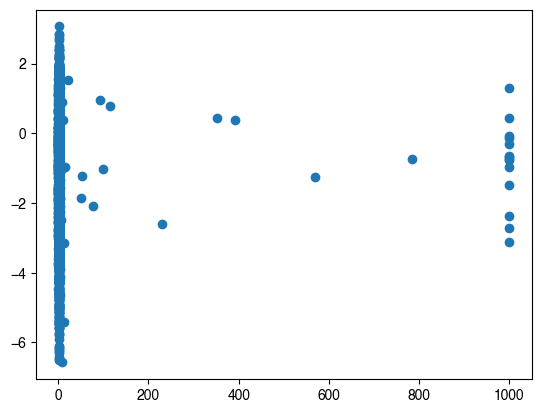

In [147]:
p_cbe_1 = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/Plasmid_base/CBE_subpool1_barcode_Plasmid_base.csv')
m1 = pd.merge(p_cbe_1, OT_merge, on='gRNA_id')

plt.scatter(m1['0'], m1['LFC_median_T0'])
scipy.stats.pearsonr(m1['0'], m1['LFC_median_T0'])

<Axes: xlabel='G_content', ylabel='LFC_median_T0'>

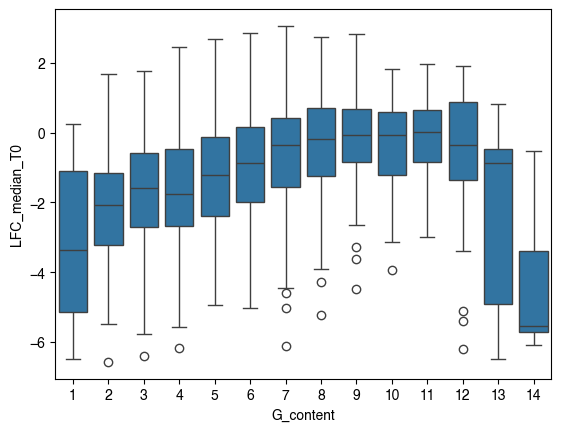

In [164]:
m1['G_content'] = [i.count('G') for i in list(m1['proto_G+19'])]
m1['A_content'] = [i.count('A') for i in list(m1['proto_G+19'])]

sns.boxplot(data=m1, x='G_content', y='LFC_median_T0')


<Axes: xlabel='A_content', ylabel='LFC_median_T0'>

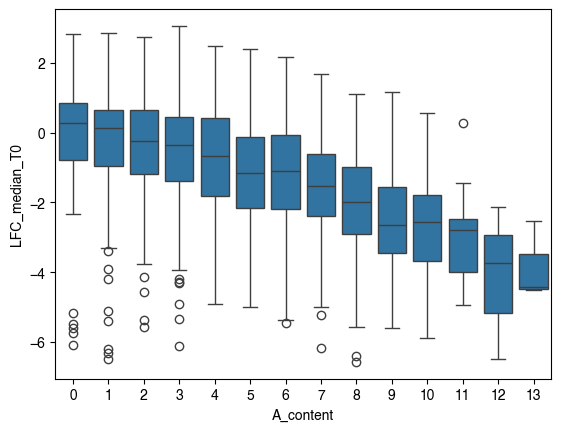

In [163]:
sns.boxplot(data=m1, x='A_content', y='LFC_median_T0')


In [150]:
m1.sort_values(by='G_content')[:30]

,gRNA_id,Gene_x,classification_x,DMSO_REP1,DMSO_REP2,DMSO_REP3,LFC_avg_DMSO,LFC_median_DMSO,base_RPM,base_RAW,...,0,1,2,3,4,proto_G+19,Gene_y,classification_y,G_content,bins
1835,gRNA_CDK19_targ_6369,CDK19,targeting,0.584165,0.486904,1.418963,0.830011,0.584165,184.241315,6538.0,...,1.0,0.0,25.0,393.0,1000.0,GGTGGTGGGGGCGCCTGTGG,CDK19,targeting,0,NaN
1828,gRNA_CDK19_targ_6362,CDK19,targeting,0.627889,0.543761,0.582970,0.584873,0.582970,349.263820,12394.0,...,1.0,0.0,20.0,216.0,1000.0,GGTGCTGTTCTGCTGTGGTG,CDK19,targeting,0,NaN
1703,gRNA_CDK9_targ_1704,CDK9,targeting,0.579795,0.450362,2.128125,1.052761,0.579795,348.925659,12382.0,...,1.0,0.0,1.0,41.0,560.0,GTGCCCTTCCGGCGCGGTGG,CDK9,targeting,0,NaN
1704,gRNA_CDK9_targ_1705,CDK9,targeting,0.549028,0.423466,0.697355,0.556616,0.549028,290.761989,10318.0,...,1.0,0.0,2.0,29.0,501.0,GGCTGCCCTTCCGGCGCGGT,CDK9,targeting,0,NaN
1705,gRNA_CDK9_targ_1706,CDK9,targeting,0.760455,0.582598,0.133422,0.492158,0.582598,300.117773,10650.0,...,1.0,0.0,5.0,60.0,930.0,GGGCTGCCCTTCCGGCGCGG,CDK9,targeting,0,NaN
2567,gRNA_CDK19_intron_8706,CDK19,intron,-0.697324,-0.683676,-0.720945,-0.700648,-0.697324,244.715750,8684.0,...,1000.0,1000.0,1000.0,1000.0,1000.0,GGTGTGTGTGTGTGTGTGTG,CDK19,intron,0,NaN
2565,gRNA_CDK19_intron_8704,CDK19,intron,-0.516760,-0.532134,-0.059196,-0.369363,-0.516760,287.549461,10204.0,...,1000.0,1000.0,1000.0,1000.0,1000.0,GGTGTGTGTGTGTGTGTGTG,CDK19,intron,0,NaN
1706,gRNA_CDK9_targ_1707,CDK9,targeting,0.849644,0.723572,0.756950,0.776722,0.756950,190.863632,6773.0,...,1.0,0.0,6.0,124.0,1000.0,GCTGGCTGCCCTTCCGGCGC,CDK9,targeting,0,NaN
1707,gRNA_CDK9_targ_1708,CDK9,targeting,0.405001,0.330630,0.865678,0.533770,0.405001,473.368859,16798.0,...,1.0,0.0,5.0,80.0,950.0,GTCTGGCTGCCCTTCCGGCG,CDK9,targeting,0,NaN
749,gRNA_CDK8_targ_750,CDK8,targeting,0.551020,0.443473,1.020247,0.671580,0.551020,462.322271,16406.0,...,1.0,0.0,8.0,114.0,1000.0,GCCGCTCCCGCTCGCTGCTC,CDK8,targeting,0,NaN


SignificanceResult(statistic=-0.37417307598120014, pvalue=1.828265097693581e-91)

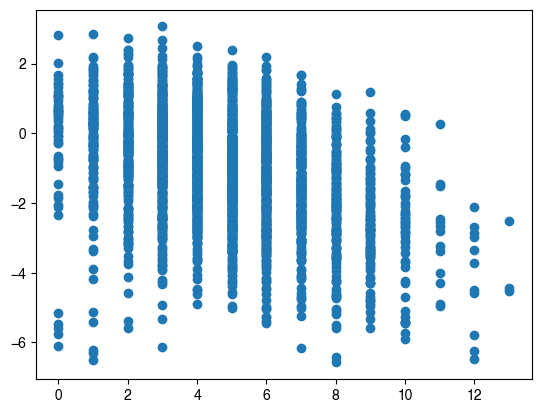

In [151]:
plt.scatter(m1['G_content'], m1['LFC_median_T0'])

scipy.stats.spearmanr(m1['G_content'], m1['LFC_median_T0'])

<Axes: xlabel='num_OT_no_mismatch', ylabel='LFC_median_T0'>

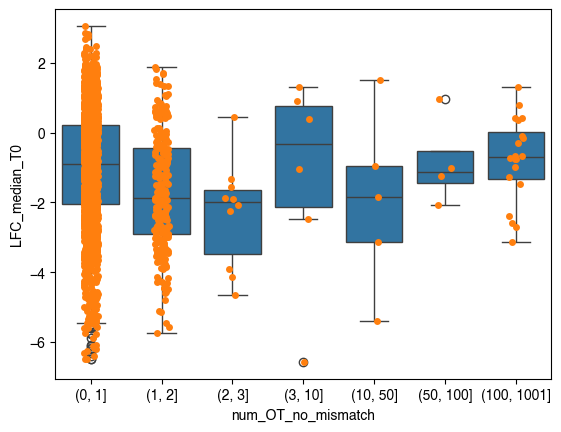

In [179]:
bins=[0,1,2,3,10,50,100,1001]
m1['num_OT_no_mismatch'] = pd.cut(m1['0'], bins=bins)
sns.boxplot(data=m1, x='num_OT_no_mismatch', y='LFC_median_T0')
sns.stripplot(data=m1, x='num_OT_no_mismatch', y='LFC_median_T0')


In [28]:
u, c = np.unique(b1[b1['Mismatches']==0]['crRNA'], return_counts=True)

np.unique(c, return_counts=True)

(array([   1,    2,    4,   40,   76,  231, 1000]),
 array([923,  43,   1,   1,   1,   1,   1]))

In [33]:
pd.DataFrame(dict(zip(['u', 'c'], [u,c]))).sort_values(by='c', ascending=False)[:30]

,u,c
967,ACTTGAGGTCAGGAGTTTGNG,1000
719,ACCATCCTGGCCAATGTGGNG,231
215,AACCTGCACATTCTACACANG,76
47,AAACCAGCCTGGCCCACATNG,40
796,ACCTGTAATACCAATACTTNG,4
77,AAAGATTTCAGAAGAAATANG,2
131,AAATGTCACATAATCTGGANG,2
97,AAAGTAAGGATTTAACCATNG,2
572,ACACCAACTGAGGAACAGTNG,2
568,ACACAGGGACCCCCGTTGANG,2


In [39]:
library[library['proto_G+19']=='GACCTGTAATACCAATACTT']

,gRNA_id,Gene,protospacer,proto_G+19,chrom,exon,proto_start,proto_end,PAM,PAM_start,...,CDS_hit,ABE_amenable,CBE_amenable,classification,nearest_exon_distance,Pool,Hamming_BC,gRNA_oligo,RE_sites,gRNA_id_OLD
8749,gRNA_CDK2_intron_8750,CDK2,CACCTGTAATACCAATACTT,GACCTGTAATACCAATACTT,12.0,intron4_5,55969125.0,55969144.0,TG,55969145.0,...,NaN,NaN,NaN,intron,196.0,F3-R3,CCCAAGCCTATGT,CAGCGCCAATGGGCTTTCGAAGCGTACACGTCTCACACCGACCTGT...,2,NaN


In [25]:
len(np.unique(b1['crRNA']))

1000